<div style="
    background-color: #f7f7f7;
    background-image: url(''), url('') ;
    background-position: left bottom, right top;
    background-repeat: no-repeat,  no-repeat;
    background-size: auto 60px, auto 160px;
    border-radius: 5px;
    box-shadow: 0px 3px 1px -2px rgba(0, 0, 0, 0.2), 0px 2px 2px 0px rgba(0, 0, 0, 0.14), 0px 1px 5px 0px rgba(0,0,0,.12);">

<h1 style="
    color: #2a4cdf;
    font-style: normal;
    font-size: 4rem;
    line-height: 1.4em;
    font-weight: 4600;
    padding: 30px 200px 0px 30px;">
    Symbolic regression: A tutorial</h1>

<p style="font-size: 1.25em; font-style: italic; padding: 5px 200px 30px 30px;">
    Tom Purcell, Emre Ahmetcik, Angelo Ziletti, Runhai Ouyang, Sbailò Luigi, Matthias Scheffler, Luca M. Ghiringhelli
</p>
</div>

<div style="margin: 10px;">
    <img style="float: left; margin: 5px 20px 0px 10px;" src="assets/logos/FAIRmat.svg" width="50">
    <img style="float: left; margin: 15px 20px 0px 0px;" src="assets/logos/nomad.svg" width="120">
    <img style="float: left; margin: 5px 20px 0px 0px;" src="assets/logos/hu-berlin.svg" width="110">
    <img style="float: left; margin: 5px 20px 0px 10px;" src="assets/logos/jupyter4nfdi.svg" width="200">
</div>
<p style="text-align: right; padding: 0px 10px 10px 0px;">[Last updated: June, 2026]</p>




This tutorial shows how to find descriptive parameters (short formulas) to predict materials properties using compressed sensing tools. As an example, we address the prediction of the zincblende (ZB) versus rocksalt (RS) relative stability of 82 octet binary materials.

The idea of using compressed sensing tools: Starting from simple physical quantities ("building blocks", here properties of the constituent free atoms such as orbital radii), millions (or billions) of candidate formulas are generated by applying arithmetic operations combining building blocks, for example forming sums and products of them. These candidate formulas constitute the so-called "feature space". Then a compressed sensing based method is used to select only a few of these formulas that explain the data, as described in 
- L. M. Ghiringhelli, J. Vybiral, S. V. Levchenko, C. Draxl, M. Scheffler: _Big Data of Materials Science: Critical Role of the Descriptor_,  Phys. Rev. Lett. 114, 105503 (2015) [[PDF]](http://journals.aps.org/prl/abstract/10.1103/PhysRevLett.114.105503)

In this tutorial we use the Sure Independence Screening and Sparsifying  Operator  (SISSO) as introduced in
- R. Ouyang, S. Curtarolo, E. Ahmetcik, M. Scheffler, L. M. Ghiringhelli: _SISSO: a compressed-sensing method for identifying the best low-dimensional descriptor in an immensity of offered candidates_, Phys. Rev. Materials  2, 083802 (2018) [[PDF]](https://journals.aps.org/prmaterials/abstract/10.1103/PhysRevMaterials.2.083802)


## Introduction to the compressed sensing methods

The feature space is generated by creating a list of analytical expressions (the derived features), obtained by combining <i> primary features </i> and arithmetic operations. In this example, the primary features are properties of isolated atoms, such as electron affinity or the radial extension of valence orbitals. We put all $m$ derived features into a descriptor matrix $\mathbf{D} \in \mathbb{R}^{82 \times m}$ where each column stands for a derived feature and each row for a compound. An $\ell_0$-regularization 

$$\text{argmin}_{\mathbf{c} \in \mathbb{R}^{m}} \{\|\mathbf{P} - \mathbf{D}\mathbf{c}\|^2_2 +\lambda \|\mathbf{c}\|_0\}$$

determines those few feature columns which approximate a property vector $\mathbf{P} \in \mathbb{R}^{82}$ (i.e RS vs. ZB energy differences) best. The subscript 0 stands for the $\ell_0$-quasinorm, that counts the number of non-zero elements of $\mathbf{c}$ and $\lambda > 0$ is called the regularization parameter. Performing the $\ell_0$-regularization becomes fast computational infeasable and often approximations (i.e. LASSO, orthogonal matching pursuit) are needed since in practice the $\ell_0$-regularization needs to be solved combinatorial: All singletons, pairs, triplets, ... $n$-tuples (up to the selected maximum dimension of the descriptor) are listed and for each set a least-square regression is performed. The $n$-tuple that gives the lowest mean square error for the least-square regression fit is selected as the resulting $n$-dimensional descriptor.

### The LASSO method
A convex optimization problem can be introduced by the Least Absolute Shrinkage and Selection Operator (LASSO):

$$\text{argmin}_{\mathbf{c} \in \mathbb{R}^{m}} \{\|\mathbf{P} - \mathbf{D}\mathbf{c}\|^2_2 +\lambda \|\mathbf{c}\|_1\}.$$

Under certain conditions on the matrix $\mathbf{D}$, it can find the exact solution of, or a good approximation to, the $\ell_0$-regularization problem.


### The SISSO method
SISSO works iteratively. In the first iteration, a number $k$ of features is collected that have the largest correlation (scalar product) with $\mathbf{P}$. The feature with the largest correlation is simply the 1D descriptor. Next, a residual is constructed as the error made in the first iteration. A new set of $k$ features is now selected as those having the largest correlation with the residual. The 2D descriptor is the pair of features that yield the smallest fitting error upon least-square regression, among all possible pairs contained in the union of the sets selected in this and the first iteration. In each next iteration a new residual is constructed as the error made in the previous iteration, then a new set of $k$ features is extracted as those that have largest correlation with each new residual. The $n$D descriptor is the $n$-tuple of features that yield the smallest fitting error upon least square regression, among all possible $n$-tuples contained in the union of the sets obtained in each new iteration and all the previous iterations. If $k=1$ the method collapses to the so-called orthogonal matching pursuit.

<center><img src="./assets/SISSO.png"/></center>




# Import required modules

In [1]:
import os
import shutil
import contextlib

import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib.pyplot as plt

from time import time
from pathlib import Path
from IPython.display import Markdown
from itertools import combinations

from ase import Atoms

from sklearn.linear_model import Lasso
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV, LeaveOneOut

from compressed_sensing.combine_features import combine_features
from compressed_sensing.scatter_plot import show_scatter_plot

from sissopp import FeatureSpace, SISSORegressor, Unit
from sissopp.py_interface import read_csv

from sissopp.sklearn import cwd, SISSORegressor as SISSORegressor_skl

from bokeh.io import output_notebook
output_notebook()

Loading BokehJS ...

# Get the data
Let us load the data from the NOMAD Archive and the atomicfeaturespackage. It consists of RS-ZB energy differences (in eV/atom) of the 82 octet binary compounds, structural information (e.g. atomic positions) of the materials, and properties of the atomic constituents. The following atomic features are considered:

- `Z`:  atomic number
- `period`: period in the periodic table
- `IP`: ionization potential
- `EA`: electron affinity
- `E_HOMO`: energy of the highest occupied atomic orbital
- `E_LUMO`: energy of the lowest unoccupied atomic orbital
- `r_(s, p, d)`: radius where the radial distribution of s, p or d orbital has its maximum.


In [2]:
df_features = pd.read_hdf('compressed_sensing.hdf5', 'features')
df_features

,Z,r_s,r_p,r_d,period,EA,IP,E_HOMO,E_LUMO
Li,3,1.65,2.00,6.93,2,-0.6981,-5.329100,-2.874,-0.978
Be,4,1.08,1.21,2.88,2,0.6305,-9.459400,-5.600,-2.098
B,5,0.81,0.83,1.95,2,-0.1074,-8.190000,-3.715,2.248
C,6,0.64,0.63,1.63,2,-0.8724,-10.851700,-5.416,1.992
N,7,0.54,0.51,1.54,2,-1.8675,-13.585200,-7.239,3.057
O,8,0.46,0.43,2.22,2,-3.0059,-16.433201,-9.197,2.541
F,9,0.41,0.37,1.43,2,-4.2735,-19.404301,-11.294,1.251
Na,11,1.71,2.60,6.57,3,-0.7157,-5.223100,-2.819,-0.718
Mg,12,1.33,1.90,3.17,3,0.6925,-8.037100,-4.782,-1.358
Al,13,1.09,1.39,1.94,3,-0.3125,-5.780500,-2.784,0.695


In [3]:
def load_target(filename):
    df = pd.read_hdf(filename, 'target')

    structures = []
    for _, row in df.iterrows():
        atoms = Atoms([row['A'], row['B']], positions=row['atomic_positions'], cell=row['lattice_vectors'], pbc=True)
        structures.append(atoms)

    return df[['A', 'B', 'energy_diff', 'min_struc_type']], structures


df_target, structures = load_target('compressed_sensing.hdf5')
df_target

,A,B,energy_diff,min_struc_type
compound,,,,
AgBr,Ag,Br,-0.030033,RS
AgCl,Ag,Cl,-0.042797,RS
AgF,Ag,F,-0.153758,RS
AgI,Ag,I,0.036925,ZB
AlAs,Al,As,0.213262,ZB
...,...,...,...,...
SrTe,Sr,Te,-0.379295,RS
ZnO,Zn,O,0.101968,ZB
ZnS,Zn,S,0.275813,ZB


Sort `A` and `B` in chemical formula `AB` with respect to electronegativity of `A` and `B`:

In [ ]:
def sort_AB_wrt_electronegativity(df_target, df_features):

    df_features['EN'] = -(df_features['IP'] + df_features['EA'])/2
    df_en = df_target[['A', 'B']].merge(df_features['EN'], left_on='A', right_index=True)
    df_en = df_en.merge(df_features['EN'], left_on='B', right_index=True, suffixes=('_A', '_B'),)
    df_en = df_en.sort_index()

    AB = np.where(df_en['EN_A'] < df_en['EN_B'], [df_en['A'], df_en['B']], [df_en['B'], df_en['A']])

    df_target.index = np.where(AB[0] == AB[1], AB[0]+'2', AB.sum(0),)
    df_target[['A', 'B',]] = AB.T

    df_features.drop('EN', axis=1, inplace=True)

    return df_target

df_target = sort_AB_wrt_electronegativity(df_target, df_features)

Merge target and feature data frames:

In [ ]:
def merge_target_feature(df_target, df_features, suffixes=('(A)', '(B)')):

    df = df_target.merge(df_features, left_on='A', right_index=True)
    df = df.merge(df_features, left_on='B', right_index=True, suffixes=suffixes)

    return df

df = merge_target_feature(df_target, df_features)
df

,A,B,energy_diff,min_struc_type,Z(A),r_s(A),r_p(A),r_d(A),period(A),EA(A),...,E_LUMO(A),Z(B),r_s(B),r_p(B),r_d(B),period(B),EA(B),IP(B),E_HOMO(B),E_LUMO(B)
AgBr,Ag,Br,-0.030033,RS,47,1.32,1.88,2.97,5,-1.6666,...,-0.479,35,0.75,0.88,1.87,4,-3.7393,-12.649600,-8.001,0.708
AgCl,Ag,Cl,-0.042797,RS,47,1.32,1.88,2.97,5,-1.6666,...,-0.479,17,0.68,0.76,1.67,3,-3.9708,-13.901800,-8.700,0.574
AgF,Ag,F,-0.153758,RS,47,1.32,1.88,2.97,5,-1.6666,...,-0.479,9,0.41,0.37,1.43,2,-4.2735,-19.404301,-11.294,1.251
AgI,Ag,I,0.036925,ZB,47,1.32,1.88,2.97,5,-1.6666,...,-0.479,53,0.90,1.07,1.72,5,-3.5135,-11.257100,-7.236,0.213
AlAs,Al,As,0.213262,ZB,13,1.09,1.39,1.94,3,-0.3125,...,0.695,33,0.85,1.04,2.02,4,-1.8392,-9.261900,-5.341,0.064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SrTe,Sr,Te,-0.379295,RS,38,1.91,2.55,1.20,5,0.3431,...,-1.379,52,0.94,1.14,1.83,5,-2.6660,-9.866700,-6.109,0.099
ZnO,Zn,O,0.101968,ZB,30,1.10,1.55,2.25,4,1.0807,...,-1.194,8,0.46,0.43,2.22,2,-3.0059,-16.433201,-9.197,2.541
ZnS,Zn,S,0.275813,ZB,30,1.10,1.55,2.25,4,1.0807,...,-1.194,16,0.74,0.85,2.37,3,-2.8449,-11.795100,-7.106,0.642
ZnSe,Zn,Se,0.263137,ZB,30,1.10,1.55,2.25,4,1.0807,...,-1.194,34,0.80,0.95,2.18,4,-2.7510,-10.946000,-6.654,1.316


Let us look at the distribution of the energy differences.

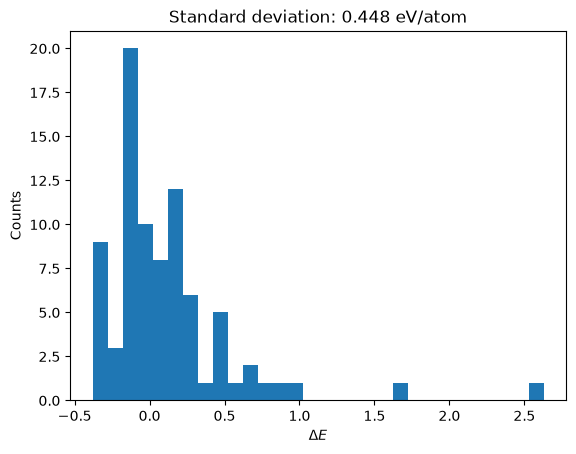

In [6]:
plt.hist(df['energy_diff'], bins=30)

std = df['energy_diff'].values.std()
plt.title(f'Standard deviation: {std:.3f} eV/atom')
plt.xlabel('$\\Delta E$')
plt.ylabel('Counts')
plt.show()

With the SISSO method, we are able to predict the energy differences from the atomic features with an accuracy of 0.035 eV/atom. However, due to computational limit we will target an accuracy of around 0.1 eV/atom in this tutorial.  

Now let us define a function get_data that uses the data frame df to define the target vector $\mathbf{P}$ of energy differences and constructs the descriptor matrix $\mathbf{D}$ of combined features. The arguments selected_feature_list and allowed_operations specify which primary features and which arithmetic operations should be used to build the new derived features.

In [ ]:
def get_data(selected_feature_list, allowed_operations):

    # add both '(A)', '(B)' to each feature
    selected_featureAB_list = [f + A_or_B for f in selected_feature_list for A_or_B in ['(A)', '(B)']]

    # extract energy differences and selected features from df
    P = df['energy_diff'].values
    df_features = df[selected_featureAB_list]

    # derive new features using allowed_operations
    df_combined = combine_features(df=df_features, allowed_operations=allowed_operations)

    return P, df_combined

In [8]:
# selected_feature_list = ['IP', 'EA', 'E_HOMO', 'E_LUMO', 'r_s', 'r_p', 'r_d', 'Z', 'period']
selected_feature_list = ['r_s', 'r_p']

# allowed_operations = ['+', '-', '|-|', '/' '^2', '^3',  'exp']
allowed_operations = ['+']

P, df_D = get_data(selected_feature_list, allowed_operations)

# print derived features
df_D

Selected operations:
 ['+']
Number of total features generated: 10


,r_s(A),r_s(B),r_p(A),r_p(B),(r_s(A)+r_s(B)),(r_s(A)+r_p(A)),(r_s(A)+r_p(B)),(r_s(B)+r_p(A)),(r_s(B)+r_p(B)),(r_p(A)+r_p(B))
AgBr,1.32,0.75,1.88,0.88,2.07,3.20,2.20,2.63,1.63,2.76
AgCl,1.32,0.68,1.88,0.76,2.00,3.20,2.08,2.56,1.44,2.64
AgF,1.32,0.41,1.88,0.37,1.73,3.20,1.69,2.29,0.78,2.25
AgI,1.32,0.90,1.88,1.07,2.22,3.20,2.39,2.78,1.97,2.95
AlAs,1.09,0.85,1.39,1.04,1.94,2.48,2.13,2.24,1.89,2.43
...,...,...,...,...,...,...,...,...,...,...
SrTe,1.91,0.94,2.55,1.14,2.85,4.46,3.05,3.49,2.08,3.69
ZnO,1.10,0.46,1.55,0.43,1.56,2.65,1.53,2.01,0.89,1.98
ZnS,1.10,0.74,1.55,0.85,1.84,2.65,1.95,2.29,1.59,2.40
ZnSe,1.10,0.80,1.55,0.95,1.90,2.65,2.05,2.35,1.75,2.50


# Determining low-dimensional descriptors with the $\ell_0$ method

<div class="alert alert-block alert-success">
    
- Perform an $\ell_0$-regularization to identify the best low dimensional descriptors using the primary features.
- Show that non-linear functions of the primary features improve the models significantly. 
- See that the $\ell_0$-regularization can rapidly become computational infeasible.
</div>

Our target is to find the best low dimensional descriptor for a linear model $\mathbf{P} = \mathbf{D^\ast}\mathbf{c^\ast}$, where $\mathbf{c^\ast}$ is the vector of nonzero elements of the solution vector $\mathbf{c}$ and $\mathbf{D^\ast}$ is the matrix of the columns of $\mathbf{D}$ corresponding to the nonzero elements of $\mathbf{c}$. The $\ell_0$ regularization

$$\text{argmin}_{\mathbf{c} \in \mathbb{R}^{m}} \{\|\mathbf{P} - \mathbf{D}\mathbf{c}\|^2_2 +\lambda \|\mathbf{c}\|_0\}$$

provides exactly what we want. It is defined in the following and solved combinatorial:


In [ ]:
def L0(P, D, dimension):

    n_rows, n_columns = D.shape
    D = np.column_stack((D, np.ones(n_rows)))
    SE_min = np.inner(P, P)
    coef_min, permu_min = None, None

    for permu in combinations(range(n_columns), dimension):
        D_ls = D[:, permu + (-1,)]
        coef, SE, __1, __2 = np.linalg.lstsq(D_ls, P, rcond=-1)
        try:
            if SE[0] < SE_min:
                SE_min = SE[0]
                coef_min, permu_min = coef, permu
        except:
            pass

    RMSE = np.sqrt(SE_min/n_rows)

    return RMSE, coef_min, permu_min

Perform the $\ell_0$-regularization for different dimensions (numbers of non-zero coefficients in the model) and see the root mean square errors (RMSE) and the selected features.

In [10]:
df_D

,r_s(A),r_s(B),r_p(A),r_p(B),(r_s(A)+r_s(B)),(r_s(A)+r_p(A)),(r_s(A)+r_p(B)),(r_s(B)+r_p(A)),(r_s(B)+r_p(B)),(r_p(A)+r_p(B))
AgBr,1.32,0.75,1.88,0.88,2.07,3.20,2.20,2.63,1.63,2.76
AgCl,1.32,0.68,1.88,0.76,2.00,3.20,2.08,2.56,1.44,2.64
AgF,1.32,0.41,1.88,0.37,1.73,3.20,1.69,2.29,0.78,2.25
AgI,1.32,0.90,1.88,1.07,2.22,3.20,2.39,2.78,1.97,2.95
AlAs,1.09,0.85,1.39,1.04,1.94,2.48,2.13,2.24,1.89,2.43
...,...,...,...,...,...,...,...,...,...,...
SrTe,1.91,0.94,2.55,1.14,2.85,4.46,3.05,3.49,2.08,3.69
ZnO,1.10,0.46,1.55,0.43,1.56,2.65,1.53,2.01,0.89,1.98
ZnS,1.10,0.74,1.55,0.85,1.84,2.65,1.95,2.29,1.59,2.40
ZnSe,1.10,0.80,1.55,0.95,1.90,2.65,2.05,2.35,1.75,2.50


In [11]:
selected_feature_list = ['r_s', 'r_p', 'r_d', 'EA', 'IP']
allowed_operations = []

P, df_D = get_data(selected_feature_list, allowed_operations)
features_list = df_D.columns.tolist()
D = df_D.values

print("     RMSE    Best descriptor")
for dim in range(1, 11):
    RMSE, coefficients, selected_indices = L0(P, D, dim)
    print(f'{dim:2}D: {RMSE:.5f}', [features_list[i] for i in selected_indices])

No allowed operations selected.
Number of total features generated: 10
     RMSE    Best descriptor
 1D: 0.31334 ['r_p(A)']
 2D: 0.29494 ['r_p(A)', 'r_d(B)']
 3D: 0.28015 ['r_s(B)', 'r_p(A)', 'r_p(B)']
 4D: 0.27525 ['IP(B)', 'r_p(A)', 'r_p(B)', 'r_d(B)']
 5D: 0.26282 ['IP(A)', 'IP(B)', 'r_p(A)', 'r_p(B)', 'r_d(B)']
 6D: 0.25090 ['IP(A)', 'IP(B)', 'r_s(A)', 'r_p(A)', 'r_p(B)', 'r_d(B)']
 7D: 0.24946 ['IP(A)', 'IP(B)', 'r_s(A)', 'r_p(A)', 'r_p(B)', 'r_d(A)', 'r_d(B)']
 8D: 0.24890 ['EA(B)', 'IP(A)', 'IP(B)', 'r_s(A)', 'r_p(A)', 'r_p(B)', 'r_d(A)', 'r_d(B)']
 9D: 0.24887 ['EA(A)', 'EA(B)', 'IP(A)', 'IP(B)', 'r_s(A)', 'r_p(A)', 'r_p(B)', 'r_d(A)', 'r_d(B)']
10D: 0.24886 ['EA(A)', 'EA(B)', 'IP(A)', 'IP(B)', 'r_s(A)', 'r_s(B)', 'r_p(A)', 'r_p(B)', 'r_d(A)', 'r_d(B)']


The result of performing the $\ell_0$-regularization shows that the accuracy converges fast, e.g. we could leave out some components in the linear model without decreasing the accuracy. The second observation is that a linear model of the atomic features is not enough to describe the RS-ZB energy differences. A way out could be using non-linear machine learning models, e.g. kernel ridge regression or a neural network, instead of linear regression. Another way is to put the non-linearity into the descriptors by building algebraic combinations of the atomic features and mapping the few best of these more complex features onto the target again with a linear model. 

Run the following script to build larger feature spaces of more complex features and select the best 1D, 2D and 3D descriptor for a linear model using $\ell_0$-regularization. Plot the results afterwards. How does the accuracy of the models change? How does the feature space size and the dimension of the descriptors depend on the needed time to solve the $\ell_0$-problem?

In [ ]:
selected_feature_list = ['r_s', 'r_p', 'r_d', 'EA', 'IP']
op_lists = [[], ['+', '|-|'], ['+', '|-|', 'exp'], ['+', '|-|', 'exp', '^2']]

X = []
prediction_errors = np.empty([3, len(op_lists)])
elapsed_time = np.empty([3, len(op_lists)])

for n_op, allowed_operations in enumerate(op_lists):
    P, df_D = get_data(selected_feature_list, allowed_operations)
    features_list = df_D.columns.tolist()
    D = df_D.values

    number_of_features = len(features_list)
    X.append(number_of_features)

    for dim in range(1, 4):
        start_time = time()
        RMSE, coefficients, selected_indices = L0(P, D, dim)
        end_time = time()

        elapsed_time[dim-1][n_op] =  end_time - start_time
        prediction_errors[dim-1][n_op] = RMSE

        print(f"n_features: {len(features_list)}; {dim}D, RMSE: {RMSE:.3f}, best features: {[features_list[i] for i in selected_indices]}")


No allowed operations selected.
Number of total features generated: 10
n_features: 10; 1D, RMSE: 0.313, best features: ['r_p(A)']
n_features: 10; 2D, RMSE: 0.295, best features: ['r_p(A)', 'r_d(B)']
n_features: 10; 3D, RMSE: 0.280, best features: ['r_s(B)', 'r_p(A)', 'r_p(B)']
Selected operations:
 ['+', '|-|']
Number of total features generated: 52
n_features: 52; 1D, RMSE: 0.297, best features: ['(r_p(A)+r_d(B))']
n_features: 52; 2D, RMSE: 0.266, best features: ['(r_p(A)+r_d(B))', '|r_p(A)-r_d(B)|']
n_features: 52; 3D, RMSE: 0.210, best features: ['|r_s(A)-r_p(A)|', '(r_s(A)+r_d(B))', '(r_p(A)+r_d(B))']
Selected operations:
 ['+', '|-|', 'exp']
Number of total features generated: 73
n_features: 73; 1D, RMSE: 0.297, best features: ['(r_p(A)+r_d(B))']
n_features: 73; 2D, RMSE: 0.228, best features: ['(r_s(B)+r_p(A))', 'exp(r_s(B)+r_p(A))']
n_features: 73; 3D, RMSE: 0.201, best features: ['|r_s(B)-r_p(A)|', '|r_s(B)-r_p(B)|', 'exp(r_p(A))']
Selected operations:
 ['+', '|-|', 'exp', '^2'

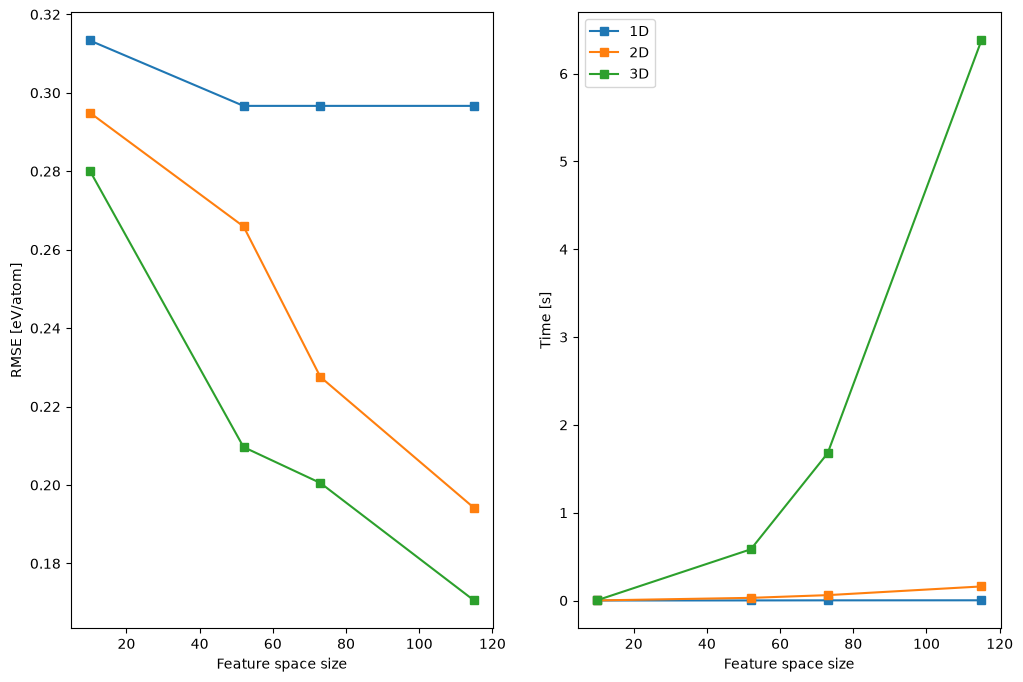

In [13]:
# plot
f, (ax1, ax2) = plt.subplots(1, 2, sharex=True, figsize=(12, 8))

ax1.set_xlabel('Feature space size')
ax1.set_ylabel('RMSE [eV/atom]')

ax2.set_xlabel('Feature space size')
ax2.set_ylabel('Time [s]')
# ax2.set_yscale('log')

for dim in range(1, 4):
    ax1.plot(X, prediction_errors[dim-1], 's-', label=f'{dim}D')
    ax2.plot(X, elapsed_time[dim-1], 's-', label=f'{dim}D')
ax2.legend(loc='best')
plt.show()

Assume now that we would like to include thousands or millions of (more) complex features to obtain more accurate models...

# Approximations to the $\ell_0$ method

<div class="alert alert-block alert-success">

- Perform a LASSO minimization and the SISSO method
- Compare the solutions with the ones from the $\ell_0$ method
</div>

### The LASSO


One state-of-the art approximation to the $\ell_0$ method is the LASSO: 

$$\text{argmin}_{\mathbf{c} \in \mathbb{R}^{m}} \{\|\mathbf{P} - \mathbf{D}\mathbf{c}\|^2_2 +\lambda \|\mathbf{c}\|_1\}$$

Before performing the LASSO regression we standardize the data to have mean 0 and variance 1, since otherwise the $\ell_2$-norm of a column would affect bias its contribution to the model. <br>
Note that we can use the LASSO also only for feature selection. We use then a least-square model with the selected features afterwards instead of the LASSO model directly.

In [14]:
def lasso_fit(lam, P, D, feature_list):

    D_standardized = ss.zscore(D)
    lasso = Lasso(alpha=lam)
    lasso.fit(D_standardized, P)
    coef = lasso.coef_

    # get strings of selected features
    selected_indices = coef.nonzero()[0]
    selected_features = [feature_list[i] for i in selected_indices]

    # get RMSE of LASSO model
    P_predict = lasso.predict(D_standardized)
    RMSE_LASSO = np.linalg.norm(P-P_predict) / np.sqrt(82.)

    # get RMSE for least-square fit
    D_new = D[:, selected_indices]
    D_new = np.column_stack((D_new, np.ones(82)))
    RMSE_LS = np.sqrt(np.linalg.lstsq(D_new, P, rcond=-1)[1][0]/82.)

    return RMSE_LASSO, RMSE_LS, coef, selected_features

$\lambda$ regulates the sparsity of the coefficient vector of the model. Get the data and try different $\lambda$ by adjusting the varibale lam. How good does LASSO (directly or with a least-square fit afterwards) approximate the L0-method (when the same feature space is used for both)?

In [15]:
# import Data
selected_feature_list = ['r_s', 'r_p', 'r_d', 'EA', 'IP']
allowed_operations = ['+', '|-|', 'exp', '^2']

P, df_D = get_data(selected_feature_list, allowed_operations)
D = df_D.values
features_list = df_D.columns.tolist()

Selected operations:
 ['+', '|-|', 'exp', '^2']
Number of total features generated: 115


In [16]:
# change lam between 0.02 and 0.34, e.g. 0.34, 0.30, 0.20, 0.13, 0.10, 0.02
lam = 0.2

RMSE_LASSO, RMSE_LS, coef, selected_features = lasso_fit(lam, P, D, features_list)

print(f"lambda: {lam:.3f}, dimension of descriptor: {len(selected_features)}, RMSE_LASSO: {RMSE_LASSO:.3f} RMSE_LS: {RMSE_LS:.3f}")
print(pd.DataFrame({'features': np.array(selected_features), 'abs(nonzero_coefs_LASSO)': np.abs(coef[coef.nonzero()])}))

lambda: 0.200, dimension of descriptor: 2, RMSE_LASSO: 0.357 RMSE_LS: 0.291
          features  abs(nonzero_coefs_LASSO)
0  (r_p(A)+r_p(B))                  0.017879
1  (r_p(A)+r_d(B))                  0.119308


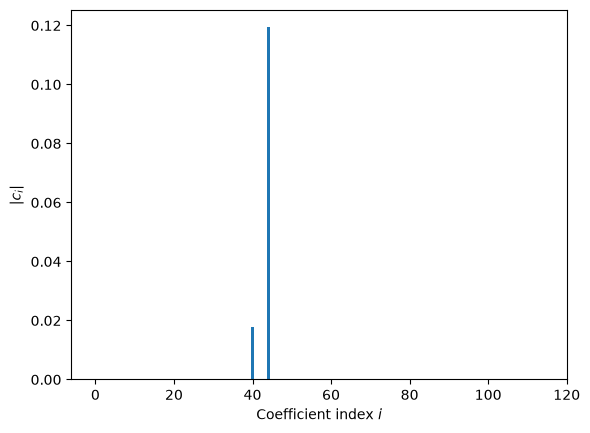

In [17]:
plt.bar(range(len(coef)), np.abs(coef))
plt.xlabel("Coefficient index $i$")
plt.ylabel("$|c_i|$")

plt.show()

<div class="alert alert-block alert-info">


**Hint:**
Compare these results to the L0 results you have obtained before from the same feature space, copied and pasted in here:
```text
Number of total features generated: 115
features: 115; 1D  RMSE: 0.296667841349  best features: ['(r_p(A)+r_d(B))']
features: 115; 2D  RMSE: 0.194137970112  best features: ['(r_s(B)+r_p(A))', '(r_s(B)+r_p(A))^2'] 
features: 115; 3D  RMSE: 0.170545592998  best features: ['(r_s(B)+r_p(A))', '(r_s(B)+r_p(A))^2', 'exp(r_s(B)+r_p(A))']"
```
</div>

# Run the SISSO method with a (relatively) big feature space

<div class="alert alert-block alert-success">

- Reproduce the results from the <a href="http://journals.aps.org/prl/abstract/10.1103/PhysRevLett.114.105503" target="_blank">reference publication</a>  by including further features.
- Visualize the 2D descriptors in a structure map.
- Experiment with different settings and investigate the influence of the input parameters on the results. (OPTIONAL)
</div>

Note the size of the feature space, the needed time to run the code and the accuracy (using the default settings)!
To deal with larger feature spaces, note that in this chapter an optimized c++ implementation of the SISSO code will be used.

Here we define a different dataframe to make it compatible with the c++ implementation of SISSO

In [ ]:
# merge target and feature data frame
df_plus = merge_target_feature(df_target, df_features, suffixes=('_A', '_B'))

# add Zunger's r_pi and r_sigma
df_plus['r_pi'] = abs(df_plus['r_p_A'] - df_plus['r_s_A']) + abs(df_plus['r_p_B'] + df_plus['r_s_B'])
df_plus['r_sigma'] = abs(df_plus['r_p_A'] + df_plus['r_s_A'] - (df_plus['r_p_B'] + df_plus['r_s_B']))

df_plus = df_plus.rename(columns={
    'Z_A': 'Z_A (nuc_charge)',
    'Z_B': 'Z_B (nuc_charge)',
    'period_A': 'period_A (unitless)',
    'period_B': 'period_B (unitless)',
    'IP_A': 'IP_A (eV_IP)',
    'IP_B': 'IP_B (eV_IP)',
    'EA_A': 'EA_A (eV_IP)',
    'EA_B': 'EA_B (eV_IP)',
    'E_HOMO_A': 'E_HOMO_A (eV)',
    'E_HOMO_B': 'E_HOMO_B (eV)',
    'E_LUMO_A': 'E_LUMO_A (eV)',
    'E_LUMO_B': 'E_LUMO_B (eV)',
})
df_plus_reduced = df_plus.drop(['A', 'B', 'min_struc_type'], axis=1)

In [19]:
n_nonzero_coefs = 3
n_features_per_sis_iter = 50
selected_features = ['r_s_A', 'r_p_A', 'r_d_A', 'EA_A', 'IP_A', 'r_s_B', 'r_p_B', 'r_d_B', 'EA_B', 'IP_B']
selected_ops = ['add', 'abs_diff', 'exp', 'sq', 'div']

inputs = read_csv(
    df_plus_reduced,
    prop_key="energy_diff",
    cols=selected_features,
    max_rung=2,
    leave_out_frac=0.0
)
inputs.allowed_ops = selected_ops
inputs.n_sis_select = n_features_per_sis_iter
inputs.n_dim = 3
inputs.max_rung = 2
inputs.n_residual = 1
# inputs.n_model_store = 1
inputs.calc_type = "regression"
inputs.leave_out_inds = []
inputs.task_sizes_train = [82]
inputs.task_sizes_test = [0]
inputs.sample_ids_train = df_plus_reduced.index.tolist()
inputs.prop_train = df_plus_reduced["energy_diff"].to_numpy()
inputs.prop_test = np.array([])
inputs.prop_label = "energy_diff"
inputs.prop_unit = Unit("eV")
inputs.task_names = ["all_mats"]

feat_space = FeatureSpace(inputs)

sisso = SISSORegressor(inputs, feat_space)
with cwd(Path("SISSO_training"), mkdir=True):
    sisso.fit()

Time to generate feat space: 0.0680789 s
Projection time: 0.0150331 s
Time to get best features on rank : 6.07446e-05 s
|---Complete final combination/selection from all ranks: 0.000240905 s
Time for SIS: 0.0164435 s
Time for l0-norm: 0.0155987 s
Projection time: 0.0179005 s
Time to get best features on rank : 5.82524e-05 s
|---Complete final combination/selection from all ranks: 0.00021481 s
Time for SIS: 0.0301288 s
Time for l0-norm: 0.0168144 s
Projection time: 0.0129129 s
Time to get best features on rank : 7.17137e-05 s
|---Complete final combination/selection from all ranks: 0.000223139 s
Time for SIS: 0.0176608 s
Time for l0-norm: 0.300356 s


In [20]:
for i in range(n_nonzero_coefs):
    print(f'{i + 1}D model')
    print(f'RMSE: {sisso.models[i][0].rmse:7.4f} | Descriptor: {sisso.models[i][0]}')

    c_params = f'c0:{sisso.models[i][0].coefs[0][-1]:7.4f}'
    a_params = ' | '.join(f'a{j}:{sisso.models[i][0].coefs[0][j]:7.4f}' for j in range(i + 1))
    print(' | '.join((c_params, a_params)))
    print('')

1D model
RMSE:  0.1328 | Descriptor: c0 + a0 * ((IP_B / r_p_A) / (r_s_A^2))
c0:-0.2816 | a0:-0.0722

2D model
RMSE:  0.1002 | Descriptor: c0 + a0 * ((|r_p_B - r_s_A|) / exp(r_s_A)) + a1 * ((|IP_B - EA_B|) / (r_p_A^2))
c0:-0.1447 | a0:-1.4825 | a1: 0.1143

3D model
RMSE:  0.0750 | Descriptor: c0 + a0 * ((r_d_B / r_d_A) / (IP_B^2)) + a1 * ((|r_p_B - r_s_A|) / exp(r_s_A)) + a2 * ((|IP_B - EA_B|) / (r_p_A^2))
c0: 0.0048 | a0:-11.9670 | a1:-1.8694 | a2: 0.1126



Next, plot an interactive 2D structure map using the 2D descriptor. Run the SISSO method for 2 non zero coefficients.

In [21]:
n_nonzero_coefs = 2
n_features_per_sis_iter = 50
selected_features = ['r_s_A', 'r_p_A', 'r_d_A', 'EA_A',
                     'IP_A', 'r_s_B', 'r_p_B', 'r_d_B', 'EA_B', 'IP_B']
selected_ops = ['add', 'abs_diff', 'exp', 'sq', 'div']

inputs = read_csv(
    df_plus_reduced,
    prop_key="energy_diff",
    cols=selected_features,
    max_rung=2,
    leave_out_frac=0.0
)

inputs.allowed_ops = selected_ops
inputs.n_sis_select = n_features_per_sis_iter
inputs.n_dim = 2
inputs.max_rung = 2
inputs.n_residual = 1
# inputs.n_model_store = 1
inputs.calc_type = "regression"
inputs.leave_out_inds = []
inputs.task_sizes_train = [82]
inputs.task_sizes_test = [0]
inputs.sample_ids_train = df_plus_reduced.index.tolist()
inputs.prop_train = df_plus_reduced["energy_diff"].to_numpy()
inputs.prop_test = np.array([])
inputs.prop_label = "energy_diff"
inputs.prop_unit = Unit("eV")
inputs.task_names = ["all_mats"]

feat_space = FeatureSpace(inputs)

sisso = SISSORegressor(inputs, feat_space)

with cwd(Path("SISSO_training"), mkdir=True):
    sisso.fit()

Time to generate feat space: 0.0794352 s
Projection time: 0.00859305 s
Time to get best features on rank : 4.57261e-05 s
|---Complete final combination/selection from all ranks: 0.000147227 s
Time for SIS: 0.0100959 s
Time for l0-norm: 0.00325787 s
Projection time: 0.00890838 s
Time to get best features on rank : 5.81518e-05 s
|---Complete final combination/selection from all ranks: 0.000209382 s
Time for SIS: 0.0108981 s
Time for l0-norm: 0.00245856 s


In [22]:
for i in range(n_nonzero_coefs):
    print(f'{i + 1}D model')
    print(f'RMSE: {sisso.models[i][0].rmse:7.4f} | Descriptor: {sisso.models[i][0]}')

    c_params = f'c0:{sisso.models[i][0].coefs[0][-1]:7.4f}'
    a_params = ' | '.join(f'a{j}:{sisso.models[i][0].coefs[0][j]:7.4f}' for j in range(i + 1))
    print(' | '.join((c_params, a_params)))
    print(sisso.models[i][0].latex_str)
    display(Markdown('$' + sisso.models[i][0].latex_str + '$' ))
    print('')

1D model
RMSE:  0.1328 | Descriptor: c0 + a0 * ((IP_B / r_p_A) / (r_s_A^2))
c0:-0.2816 | a0:-0.0722
$c_0 + a_0\left(\frac{ \left(\frac{ IP_{B} }{ r_{p, A} } \right) }{ \left(r_{s, A}^2\right) } \right)$


$$c_0 + a_0\left(\frac{ \left(\frac{ IP_{B} }{ r_{p, A} } \right) }{ \left(r_{s, A}^2\right) } \right)$$


2D model
RMSE:  0.1002 | Descriptor: c0 + a0 * ((|r_p_B - r_s_A|) / exp(r_s_A)) + a1 * ((|IP_B - EA_B|) / (r_p_A^2))
c0:-0.1447 | a0:-1.4825 | a1: 0.1143
$c_0 + a_0\left(\frac{ \left(\left|r_{p, B} - r_{s, A}\right|\right) }{ \left(\exp{ r_{s, A} }\right) } \right) + a_1\left(\frac{ \left(\left|IP_{B} - EA_{B}\right|\right) }{ \left(r_{p, A}^2\right) } \right)$


$$c_0 + a_0\left(\frac{ \left(\left|r_{p, B} - r_{s, A}\right|\right) }{ \left(\exp{ r_{s, A} }\right) } \right) + a_1\left(\frac{ \left(\left|IP_{B} - EA_{B}\right|\right) }{ \left(r_{p, A}^2\right) } \right)$$

Below the plot containing all octet binary materials, shown in the coordinate reference system given by the SISSO descriptors. By hovering over a point in the plot, information regarding that compound is displayed. By clicking a point, an interactive 3D visualization of the most stable structure will be displayed below the plot. To facilitate comparison between different materials, we make available two separate viewers. The specific viewer to be employed for visualization can be selected with a check box placed on top-right of each visualizer. Once a compound is selected from the plot, the marker on the plot changes shape accordingly to a marker that is specific of the viewer and whose shape is shown next to the checkbox. The name of the compound viewed is shown on top of the visualizer, and it is also possible to modify the name in the text box with the name of another compound, which can be displayed by clicking the "Display" button. Consequently, the new compound is also marked on the plot, that allows to easily identify the position of each compound in the plot. Note that the structures of all compounds were stored in a .xyz file at the beginning of the tutorial, i.e. using the function 'write_xyz'.

The markers represent the compounds and their colors the reference energy differences. How well does the descriptor separate the compounds with respect to their crystal structure?

In [23]:
# import nglview as nv

# # Pass the ASE molecule to NGLView

# view = nv.show_ase(structures[65].repeat((3, 3, 3)))

# # Customize the view (optional)
# view.add_ball_and_stick()
# view.add_unitcell()

# # Display the widget in your Jupyter environment
# view

In [24]:
# import nglview as nv

# # Pass the ASE molecule to NGLView
# view = nv.show_ase(a.repeat(3))

# # Customize the view (optional)
# view.add_ball_and_stick()

# # Display the widget in your Jupyter environment
# view

In [25]:

# import nglview as nv
# from ase.io import read

# # Load your .xyz file
# molecule = read('data/compressed_sensing/structures/AgCl.xyz')

# # Pass the ASE molecule to NGLView
# view = nv.show_ase(molecule)

# # Customize the view (optional)
# view.add_ball_and_stick()

# # Display the widget in your Jupyter environment
# view

In [33]:
import plotly.graph_objects as go
import ipywidgets as widgets
# from jupyter_jsmol import JsmolView
import numpy as np
from IPython.display import display, HTML, FileLink
import os
import pandas as pd



In [42]:

class Visualizer:

    def __init__(self, df, sisso, feat_space):

        self.marker_size = 7
        self.marker_symbol_RS = 'circle'
        self.marker_symbol_ZB = 'square'
        self.symbols = [
            'circle',
            'square',
            'triangle-up',
            'triangle-down',
            'circle-cross',
            'circle-x'
        ]
        self.font_size = 12
        self.cross_size = 15
        self.line_width = 1
        self.font_families = ['Source Sans Pro',
                              'Helvetica',
                              'Open Sans',
                              'Times New Roman',
                              'Arial',
                              'Verdana',
                              'Courier New',
                              'Comic Sans MS',
                              ]
        self.line_styles = ["dash",
                            "solid",
                            "dot",
                            "longdash",
                            "dashdot",
                            "longdashdot"]
        self.gradient_list = ['Blue to red',
                              'Blue to green',
                              'Green to red',
                              'Grey scale',
                              'Purple scale',
                              'Turquoise scale']
        self.bg_color = 'rgba(229,236,246, 0.5)'
        self.zb_color = "#EB8273"
        self.rs_color = "rgb(138, 147, 248)"
        self.df = df
        self.sisso = sisso
        self.feat_space = feat_space
        self.total_features = sisso.n_dim
        self.feat_val_list = list(reversed([feat.value for feat in sisso.models[sisso.n_dim - 1][0].feats]))
        self.features = list(reversed([str(feat.expr) for feat in sisso.models[sisso.n_dim - 1][0].feats]))
        self.df_selected = pd.DataFrame()
        for feat, values in zip(self.features, self.feat_val_list):
            self.df_selected[feat] = values
        self.df_selected['Structure'] = df.reset_index()['min_struc_type']
        self.df_selected['Chem Formula'] = df.index.to_numpy()

        self.coefficients = list(reversed(self.sisso.models[sisso.n_dim - 1][0].coefs[0][:-1]))
        self.intercept = self.sisso.models[sisso.n_dim - 1][0].coefs[0][-1]
        self.target_predict = sisso.models[sisso.n_dim - 1][0].fit
        self.target_train = sisso.models[sisso.n_dim - 1][0].prop_train
        self.bg_toggle = True
        self.compounds_list = df.index.tolist()
        self.df_RS = df['min_struc_type'] == 'RS'
        self.df_ZB = df['min_struc_type'] == 'ZB'
        self.RS_npoints = len(self.df_RS)
        self.ZB_npoints = len(self.df_ZB)
        self.RS_symbols = [self.marker_symbol_RS] * self.RS_npoints
        self.ZB_symbols = [self.marker_symbol_ZB] * self.ZB_npoints
        self.RS_sizes = [self.marker_size] * self.RS_npoints
        self.ZB_sizes = [self.marker_size] * self.ZB_npoints
        self.RS_colors = [self.rs_color] * self.RS_npoints
        self.ZB_colors = [self.zb_color] * self.ZB_npoints

        self.fig = go.FigureWidget()
        self.viewer_l = 0
        self.viewer_r = 0
        self.instantiate_widgets()
        line_x, line_y = self.f_x(self.features[0], self.features[1])
        self.line_x = line_x
        self.line_y = line_y
        custom_RS = np.dstack((self.target_train[self.df_RS],
                               self.target_predict[self.df_RS]))[0]
        custom_ZB = np.dstack((self.target_train[self.df_ZB],
                               self.target_predict[self.df_ZB]))[0]

        # the final plot is the sum of two traces, respectively containing the RS vs ZB materials
        x_RS = self.feat_val_list[0][self.df_RS]
        y_RS = self.feat_val_list[1][self.df_RS]
        x_ZB = self.feat_val_list[0][self.df_ZB]
        y_ZB = self.feat_val_list[1][self.df_ZB]

        self.fig.add_trace(
            (
                go.Scatter(
                    mode='markers',
                    x=x_RS,
                    y=y_RS,
                    customdata=custom_RS,
                    text=df[self.df_RS].index.to_numpy(),
                    hovertemplate=
                    r"<b>%{text}</b><br><br>" +
                    "x axis: %{x:,.2f}<br>" +
                    "y axis: %{y:,.2f}<br>" +
                    "ΔE reference:  %{customdata[0]:,.4f}<br>" +
                    "ΔE predicted:  %{customdata[1]:,.4f}<br>",
                    name='RS',
                    marker=dict(color=self.RS_colors)
                )
            ))
        self.fig.add_trace(
            (
                go.Scatter(
                    mode='markers',
                    x=x_ZB,
                    y=y_ZB,
                    customdata=custom_ZB,
                    text=df[self.df_ZB].index.to_numpy(),
                    hovertemplate=
                    r"<b>%{text}</b><br><br>" +
                    "x axis: %{x:,.2f}<br>" +
                    "y axis: %{y:,.2f}<br>" +
                    "ΔE reference:  %{customdata[0]:,.4f}<br>" +
                    "ΔE predicted:  %{customdata[1]:,.4f}<br>",
                    name='ZB',
                    marker=dict(color=self.ZB_colors)
                )
            ))
        self.fig.add_trace(
            go.Scatter(
                x=self.line_x,
                y=self.line_y,
                line=dict(color='Grey', width=1, dash=self.line_styles[0]),
                name=r'Classification' + '<br>' + 'line',
                visible=False
            ),
        )

        x_min = min(min(x_RS), min(x_ZB))
        y_min = min(min(y_RS), min(y_ZB))
        x_max = max(max(x_RS), max(x_ZB))
        y_max = max(max(y_RS), max(y_ZB))
        x_delta = 0.05 * abs(x_max - x_min)
        y_delta = 0.05 * abs(y_max - y_min)
        self.fig.update_layout(
            plot_bgcolor=self.bg_color,
            font=dict(
                size=int(self.font_size),
                family=self.font_families[0]
            ),
            xaxis_title=self.features[0],
            yaxis_title=self.features[1],
            xaxis_range=[x_min - x_delta, x_max + x_delta],
            yaxis_range=[y_min - y_delta, y_max + y_delta],
            hoverlabel=dict(
                bgcolor="white",
                font_size=16,
                font_family="Rockwell"
            ),
            width=800,
            height=400,
            margin=dict(
                l=50,
                r=50,
                b=70,
                t=20,
                pad=4
            ),
        )

        self.scatter_RS = self.fig.data[0]
        self.scatter_ZB = self.fig.data[1]
        self.scatter_line = self.fig.data[2]
        if self.total_features == 2:
            self.scatter_line.visible = True
        else:
            self.widg_linewidth.disabled = True
            self.widg_linestyle.disabled = True

        self.update_markers()

    def f_x(self, feat_x, feat_y):

        idx_x = self.features.index(feat_x)
        idx_y = self.features.index(feat_y)
        line_x = np.linspace(self.df_selected[feat_x].min(), self.df_selected[feat_x].max(), 1000)

        # Gives the classifications line
        if self.widg_featx.value == self.widg_featy.value:
            return line_x, line_x
        else:
            # print('x',  self.coefficients[self.current_features[idx_x]])
            # print('y',  self.coefficients[self.current_features[idx_y]])
            line_y = -line_x * self.coefficients[idx_x] / self.coefficients[idx_y] - self.intercept / self.coefficients[
                idx_y]
            return line_x, line_y

    def update_markers(self):
        # Markers size and symbol are updated simultaneously
        with self.fig.batch_update():
            self.scatter_RS.marker.size = self.RS_sizes
            self.scatter_ZB.marker.size = self.ZB_sizes
            self.scatter_RS.marker.symbol = self.RS_symbols
            self.scatter_ZB.marker.symbol = self.ZB_symbols
            self.scatter_RS.marker.color = self.RS_colors
            self.scatter_ZB.marker.color = self.ZB_colors

    def set_markers_size(self, feature='Default size'):
        # Defines the size of the markers based on the input feature.
        # In case of default feature all markers have the same size.
        # Points marked with x/cross are set with a specific size

        if feature == 'Default size':

            sizes_RS = [self.marker_size] * self.RS_npoints
            sizes_ZB = [self.marker_size] * self.ZB_npoints
            symbols_RS = self.RS_symbols
            symbols_ZB = self.ZB_symbols

            try:
                point = symbols_RS.index('x')
                sizes_RS[point] = self.cross_size
            except:
                try:
                    point = symbols_ZB.index('x')
                    sizes_ZB[point] = self.cross_size
                except:
                    pass
            try:
                point = symbols_RS.index('cross')
                sizes_RS[point] = self.cross_size
            except:
                try:
                    point = symbols_ZB.index('cross')
                    sizes_ZB[point] = self.cross_size
                except:
                    pass

            self.RS_sizes = sizes_RS
            self.ZB_sizes = sizes_ZB
        else:
            min_value = min(min(self.df_selected.loc[self.df_selected['Structure'] == 'RS'][feature]),
                            min(self.df_selected.loc[self.df_selected['Structure'] == 'ZB'][feature]))
            max_value = max(max(self.df_selected.loc[self.df_selected['Structure'] == 'RS'][feature]),
                            max(self.df_selected.loc[self.df_selected['Structure'] == 'ZB'][feature]))
            coeff = 2 * self.marker_size / (max_value - min_value)
            sizes_RS = self.marker_size / 2 + coeff * self.df_selected.loc[self.df_selected['Structure'] == 'RS'][
                feature]
            sizes_ZB = self.marker_size / 2 + coeff * self.df_selected.loc[self.df_selected['Structure'] == 'ZB'][
                feature]
            self.RS_sizes = sizes_RS
            self.ZB_sizes = sizes_ZB

    def make_colors(self, feature, gradient):

        if feature == 'Default color':

            self.RS_colors = [self.rs_color] * self.RS_npoints
            self.ZB_colors = [self.zb_color] * self.ZB_npoints

        else:

            min_value = self.df_selected[feature].min()
            max_value = self.df_selected[feature].max()
            shade_RS = 0.7*(self.df_selected.loc[self.df_selected['Structure'] == 'RS'][feature].to_numpy() - min_value)/\
                         (max_value-min_value)
            shade_ZB = 0.7*(self.df_selected.loc[self.df_selected['Structure'] == 'ZB'][feature].to_numpy() - min_value)/\
                         (max_value-min_value)

            if gradient == 'Grey scale':
                for i, e in enumerate(shade_RS):
                    value = 255*(0.7-e)
                    string = 'rgb('+str(value)+","+str(value)+","+str(value)+')'
                    self.RS_colors[i] = string
                for i, e in enumerate(shade_ZB):
                    value = 255*(0.7-e)
                    string = 'rgb('+str(value)+","+str(value)+","+str(value)+')'
                    self.ZB_colors[i] = string

            if gradient == 'Purple scale':
                for i, e in enumerate(shade_RS):
                    value = 255 * (0.7 - e)
                    string = 'rgb(' + str(value) + "," + str(0) + "," + str(value) + ')'
                    self.RS_colors[i] = string
                for i, e in enumerate(shade_ZB):
                    value = 255 * (0.7 - e)
                    string = 'rgb(' + str(value) + "," + str(0) + "," + str(value) + ')'
                    self.ZB_colors[i] = string

            if gradient == 'Turquoise scale':
                for i, e in enumerate(shade_RS):
                    value = 255 * (0.7 - e)
                    string = 'rgb(' + str(0) + "," + str(value) + "," + str(value) + ')'
                    self.RS_colors[i] = string
                for i, e in enumerate(shade_ZB):
                    value = 255 * (0.7 - e)
                    string = 'rgb(' + str(0) + "," + str(value) + "," + str(value) + ')'
                    self.ZB_colors[i] = string

            shade_RS = 0.7 * (
                        self.df_selected.loc[self.df_selected['Structure'] == 'RS'][feature].to_numpy() - min_value) / \
                       (max_value - min_value)
            shade_ZB = 0.7 * (
                        self.df_selected.loc[self.df_selected['Structure'] == 'ZB'][feature].to_numpy() - min_value) / \
                       (max_value - min_value)
            if gradient == 'Blue to green':
                for i, e in enumerate(shade_RS):
                    value = 255 * e
                    value2 = 255 - value
                    string = 'rgb(' + str(0) + "," + str(value) + "," + str(value2) + ')'
                    self.RS_colors[i] = string
                for i, e in enumerate(shade_ZB):
                    value = 255 * e
                    value2 = 255 - value
                    string = 'rgb(' + str(0) + "," + str(value) + "," + str(value2) + ')'
                    self.ZB_colors[i] = string

            if gradient == 'Blue to red':
                for i, e in enumerate(shade_RS):
                    value = 255 * e
                    value2 = 255 - value
                    string = 'rgb(' + str(value) + "," + str(0) + "," + str(value2) + ')'
                    self.RS_colors[i] = string
                for i, e in enumerate(shade_ZB):
                    value = 255 * e
                    value2 = 255 - value
                    string = 'rgb(' + str(value) + "," + str(0) + "," + str(value2) + ')'
                    self.ZB_colors[i] = string

            if gradient == 'Green to red':
                for i, e in enumerate(shade_RS):
                    value = 255 * e
                    value2 = 255 - value
                    string = 'rgb(' + str(value) + "," + str(value2) + "," + str(0) + ')'
                    self.RS_colors[i] = string
                for i, e in enumerate(shade_ZB):
                    value = 255 * e
                    value2 = 255 - value
                    string = 'rgb(' + str(value) + "," + str(value2) + "," + str(0) + ')'
                    self.ZB_colors[i] = string

    def handle_xfeat_change(self, change):
        # changes the feature plotted on the x-axis
        # separating line is modified accordingly
        self.fig.update_layout(
            xaxis_title=change.new,
        )
        self.scatter_RS['x'] = self.df_selected.loc[self.df_selected['Structure'] == 'RS'][change.new].to_numpy()
        self.scatter_ZB['x'] = self.df_selected.loc[self.df_selected['Structure'] == 'ZB'][change.new].to_numpy()
        line_x, line_y = self.f_x(change.new, self.widg_featy.value)
        self.scatter_line['x'] = line_x
        self.scatter_line['y'] = line_y
        min_x = min(min(self.scatter_RS['x']), min(self.scatter_ZB['x']))
        max_x = max(max(self.scatter_RS['x']), max(self.scatter_ZB['x']))
        min_delta = 0.05 * abs(max_x - min_x)
        self.fig.layout['xaxis'].range = [min_x - min_delta, max_x + min_delta]

    def handle_yfeat_change(self, change):
        # changes the feature plotted on the x-axis
        # separating line is modified accordingly
        self.fig.update_layout(
            yaxis_title=change.new,
        )
        self.scatter_RS['y'] = self.df_selected.loc[self.df_selected['Structure'] == 'RS'][change.new].to_numpy()
        self.scatter_ZB['y'] = self.df_selected.loc[self.df_selected['Structure'] == 'ZB'][change.new].to_numpy()

        line_x, line_y = self.f_x(self.widg_featx.value, change.new)

        self.scatter_line['x'] = line_x
        self.scatter_line['y'] = line_y
        min_y = min(min(self.scatter_RS['y']), min(self.scatter_ZB['y']))
        max_y = max(max(self.scatter_RS['y']), max(self.scatter_ZB['y']))
        min_delta = 0.05 * abs(max_y - min_y)
        self.fig.layout['yaxis'].range = [min_y - min_delta, max_y + min_delta]

    def handle_markerfeat_change(self, change):
        self.set_markers_size(feature=change.new)
        self.update_markers()

    def handle_colorfeat_change(self, change):
        if change.new == 'Default color':
            self.widg_gradient.layout.visibility = 'hidden'
            self.RS_colors = [self.rs_color] * self.RS_npoints
            self.ZB_colors = [self.zb_color] * self.ZB_npoints
        else:
            self.widg_gradient.layout.visibility = 'visible'
            self.make_colors(feature=change.new, gradient=self.widg_gradient.value)
        self.update_markers()

    def handle_gradient_change(self, change):
        self.make_colors(feature=self.widg_featcolor.value, gradient=change.new)
        self.update_markers()

    def display_button_l_clicked(self, button):

        # Actions are performed only if the string inserted in the text widget corresponds to an existing compound
        if self.widg_compound_text_l.value in self.df_selected['Chem Formula'].tolist():
            structure_l = self.df_selected[self.df_selected['Chem Formula'] ==
                                           self.widg_compound_text_l.value]['Structure'].values[0]
            self.viewer_l.script(
                "load data/compressed_sensing/structures/"
                + self.widg_compound_text_l.value + ".xyz")

            symbols_RS = self.RS_symbols
            symbols_ZB = self.ZB_symbols

            try:
                point = symbols_RS.index('x')
                symbols_RS[point] = self.marker_symbol_RS
            except:
                try:
                    point = symbols_ZB.index('x')
                    symbols_ZB[point] = self.marker_symbol_ZB
                except:
                    pass
            if structure_l == 'RS':
                point = np.where(self.scatter_RS['text'] == self.widg_compound_text_l.value)[0][0]
                symbols_RS[point] = 'x'
            if structure_l == 'ZB':
                point = np.where(self.scatter_ZB['text'] == self.widg_compound_text_l.value)[0][0]
                symbols_ZB[point] = 'x'

            self.ZB_symbols = symbols_ZB
            self.RS_symbols = symbols_RS
            self.set_markers_size(feature=self.widg_featmarker.value)
            self.update_markers()

    def display_button_r_clicked(self, button):

        # Actions are performed only if the string inserted in the text widget corresponds to an existing compound
        if self.widg_compound_text_r.value in self.df_selected['Chem Formula'].tolist():
            structure_r = self.df_selected[self.df_selected['Chem Formula'] ==
                                           self.widg_compound_text_r.value]['Structure'].values[0]
            self.viewer_r.script(
                "load data/compressed_sensing/structures/"
                + self.widg_compound_text_r.value + ".xyz")

            symbols_RS = self.RS_symbols
            symbols_ZB = self.ZB_symbols

            try:
                point = symbols_RS.index('cross')
                symbols_RS[point] = self.marker_symbol_RS
            except:
                try:
                    point = symbols_ZB.index('cross')
                    symbols_ZB[point] = self.marker_symbol_ZB
                except:
                    pass
            if structure_r == 'RS':
                point = np.where(self.scatter_RS['text'] == self.widg_compound_text_r.value)[0][0]
                symbols_RS[point] = 'cross'
            if structure_r == 'ZB':
                point = np.where(self.scatter_ZB['text'] == self.widg_compound_text_r.value)[0][0]
                symbols_ZB[point] = 'cross'

            self.RS_symbols = symbols_RS
            self.ZB_symbols = symbols_ZB
            self.set_markers_size(feature=self.widg_featmarker.value)
            self.update_markers()

    def updatecolor_button_clicked(self, button):

        if self.widg_featcolor.value == 'Default color':
            try:
                self.scatter_RS.update(marker=dict(color=self.widg_rscolor.value))
                self.rs_color = self.widg_rscolor.value
                self.RS_colors = self.RS_npoints * [self.rs_color]
            except:
                pass
            try:
                self.scatter_ZB.update(marker=dict(color=self.widg_zbcolor.value))
                self.rs_color = self.widg_rscolor.value
                self.RS_colors = self.RS_npoints * [self.rs_color]
            except:
                pass

            if self.bg_toggle:
                try:
                    self.fig.update_layout(plot_bgcolor=self.widg_bgcolor.value)
                    self.bg_color = self.widg_bgcolor.value
                except:
                    pass

    def handle_fontfamily_change(self, change):

        self.fig.update_layout(
            font=dict(family=change.new)
        )

    def handle_fontsize_change(self, change):

        self.fig.update_layout(
            font=dict(size=change.new)
        )

    def handle_markersize_change(self, change):

        self.marker_size = int(change.new)
        self.set_markers_size(feature=self.widg_featmarker.value)
        self.update_markers()

    def handle_crossize_change(self, change):

        self.cross_size = int(change.new)
        self.set_markers_size(feature=self.widg_featmarker.value)
        self.update_markers()

    def handle_linewidth_change(self, change):

        self.line_width = change.new
        self.scatter_line.update(line=dict(width=int(self.widg_linewidth.value))),

    def handle_linestyle_change(self, change):

        self.scatter_line.update(line=dict(dash=change.new))

    def handle_markersymbolrs_change(self, change):

        for i, e in enumerate(self.RS_symbols):
            if e == self.marker_symbol_RS:
                self.RS_symbols[i] = change.new
        self.marker_symbol_RS = change.new
        self.update_markers()

    def handle_markersymbolzb_change(self, change):

        for i, e in enumerate(self.ZB_symbols):
            if e == self.marker_symbol_ZB:
                self.ZB_symbols[i] = change.new
        self.marker_symbol_ZB = change.new
        self.update_markers()

    def bgtoggle_button_clicked(self, button):

        if self.bg_toggle:
            self.bg_toggle = False
            self.fig.update_layout(
                plot_bgcolor='white',
                xaxis=dict(gridcolor='rgb(229,236,246)', showgrid=True, zeroline=False),
                yaxis=dict(gridcolor='rgb(229,236,246)', showgrid=True, zeroline=False),
            )
        else:
            self.bg_toggle = True
            self.fig.update_layout(
                plot_bgcolor=self.widg_bgcolor.value,
                xaxis=dict(gridcolor='white'),
                yaxis=dict(gridcolor='white')
            )

    def print_button_clicked(self, button):

        self.widg_print_out.clear_output()
        text = "A download link will appear soon."
        with self.widg_print_out:
            print(text)
        path = "./data/compressed_sensing/plots/"
        try:
            os.mkdir(path)
        except:
            pass
        file_name = self.widg_plot_name.value + '.' + self.widg_plot_format.value
        self.fig.write_image(path + file_name, scale=self.widg_scale.value)
        self.widg_print_out.clear_output()
        with self.widg_print_out:
            local_file = FileLink(path + file_name, result_html_prefix="Click here to download: ")
            display(local_file)

    def reset_button_clicked(self, button):

        self.RS_symbols = [self.marker_symbol_RS] * self.RS_npoints
        self.ZB_symbols = [self.marker_symbol_ZB] * self.ZB_npoints
        self.set_markers_size(self.widg_featmarker.value)
        self.update_markers()


    def handle_checkbox_l(self, change):
        if change.new:
            self.widg_checkbox_r.value = False
        else:
            self.widg_checkbox_r.value = True

    def handle_checkbox_r(self, change):
        if change.new:
            self.widg_checkbox_l.value = False
        else:
            self.widg_checkbox_l.value = True

    def view_structure_l(self, formula):
        self.viewer_l.script("load data/compressed_sensing/structures/" + formula + ".xyz")

    def view_structure_r(self, formula):
        self.viewer_r.script("load data/compressed_sensing/structures/" + formula + ".xyz")

    def update_point_RS(self, trace, points, selector):
        # changes the points labeled with a cross on the map.
        if not points.point_inds:
            return

        symbols_RS = self.RS_symbols
        symbols_ZB = self.ZB_symbols

        # The element previously marked with x/cross is marked with circle as default value
        if self.widg_checkbox_l.value:
            try:
                point = symbols_RS.index('x')
                symbols_RS[point] = self.marker_symbol_RS
            except:
                try:
                    point = symbols_ZB.index('x')
                    symbols_ZB[point] = self.marker_symbol_ZB
                except:
                    pass
        if self.widg_checkbox_r.value:
            try:
                point = symbols_RS.index('cross')
                symbols_RS[point] = self.marker_symbol_RS
            except:
                try:
                    point = symbols_ZB.index('cross')
                    symbols_ZB[point] = self.marker_symbol_ZB
                except:
                    pass

        if self.widg_checkbox_l.value:
            symbols_RS[points.point_inds[0]] = 'x'
        if self.widg_checkbox_r.value:
            symbols_RS[points.point_inds[0]] = 'cross'

        self.RS_symbols = symbols_RS
        self.ZB_symbols = symbols_ZB
        self.set_markers_size(feature=self.widg_featmarker.value)
        self.update_markers()

        formula = trace['text'][points.point_inds[0]]
        if self.widg_checkbox_l.value:
            self.widg_compound_text_l.value = formula
            self.view_structure_l(formula)
        if self.widg_checkbox_r.value:
            self.widg_compound_text_r.value = formula
            self.view_structure_r(formula)

    def update_point_ZB(self, trace, points, selector):
        if not points.point_inds:
            return

        symbols_RS = self.RS_symbols
        symbols_ZB = self.ZB_symbols

        # The element previously marked with x/cross is marked with circle as default value
        if self.widg_checkbox_l.value:
            try:
                point = symbols_RS.index('x')
                symbols_RS[point] = self.marker_symbol_RS
            except:
                try:
                    point = symbols_ZB.index('x')
                    symbols_ZB[point] = self.marker_symbol_ZB
                except:
                    pass
        if self.widg_checkbox_r.value:
            try:
                point = symbols_RS.index('cross')
                symbols_RS[point] = self.marker_symbol_RS
            except:
                try:
                    point = symbols_ZB.index('cross')
                    symbols_ZB[point] = self.marker_symbol_ZB
                except:
                    pass

        if self.widg_checkbox_l.value:
            symbols_ZB[points.point_inds[0]] = 'x'
        if self.widg_checkbox_r.value:
            symbols_ZB[points.point_inds[0]] = 'cross'

        self.RS_symbols = symbols_RS
        self.ZB_symbols = symbols_ZB
        self.set_markers_size(feature=self.widg_featmarker.value)
        self.update_markers()

        formula = trace['text'][points.point_inds[0]]
        if self.widg_checkbox_l.value:
            self.widg_compound_text_l.value = formula
            self.view_structure_l(formula)
        if self.widg_checkbox_r.value:
            self.widg_compound_text_r.value = formula
            self.view_structure_r(formula)

    def show(self):

        self.widg_featx.observe(self.handle_xfeat_change, names='value')
        self.widg_featy.observe(self.handle_yfeat_change, names='value')
        self.widg_featmarker.observe(self.handle_markerfeat_change, names='value')
        self.widg_featcolor.observe(self.handle_colorfeat_change, names='value')
        self.widg_gradient.observe(self.handle_gradient_change, names='value')
        self.widg_checkbox_l.observe(self.handle_checkbox_l, names='value')
        self.widg_checkbox_r.observe(self.handle_checkbox_r, names='value')
        self.widg_display_button_l.on_click(self.display_button_l_clicked)
        self.widg_display_button_r.on_click(self.display_button_r_clicked)
        self.widg_updatecolor_button.on_click(self.updatecolor_button_clicked)
        self.widg_reset_button.on_click(self.reset_button_clicked)
        self.widg_print_button.on_click(self.print_button_clicked)
        self.widg_bgtoggle_button.on_click(self.bgtoggle_button_clicked)
        self.widg_linestyle.observe(self.handle_linestyle_change, names='value')
        self.scatter_RS.on_click(self.update_point_RS)
        self.scatter_ZB.on_click(self.update_point_ZB)
        self.widg_markersize.observe(self.handle_markersize_change, names='value')
        self.widg_crosssize.observe(self.handle_crossize_change, names='value')
        self.widg_linewidth.observe(self.handle_linewidth_change, names='value')
        self.widg_fontfamily.observe(self.handle_fontfamily_change, names='value')
        self.widg_fontsize.observe(self.handle_fontsize_change, names='value')
        self.widg_zbmarkersymbol.observe(self.handle_markersymbolzb_change, names='value')
        self.widg_rsmarkersymbol.observe(self.handle_markersymbolrs_change, names='value')

        self.output_l.layout = widgets.Layout(width="400px", height='350px')
        self.output_r.layout = widgets.Layout(width="400px", height='350px')

        with self.output_l:
            display(self.viewer_l)
        with self.output_r:
            display(self.viewer_r)

        self.widg_gradient.layout.visibility = 'hidden'

        self.box_feat.layout.height = '110px'
        self.box_feat.layout.top = '30px'



        container = widgets.VBox([
                                  self.box_feat, self.fig,
                                  self.widg_box_viewers,
                                  ])

        display(container)

    def instantiate_widgets(self):

        self.widg_featx = widgets.Dropdown(
            description='x-axis',
            options=self.features,
            value=self.features[0]
        )
        self.widg_featy = widgets.Dropdown(
            description='y-axis',
            options=self.features,
            value=self.features[1]
        )
        self.widg_featmarker = widgets.Dropdown(
            description="Marker",
            options=['Default size'] + self.features,
            value='Default size',
        )
        self.widg_featcolor = widgets.Dropdown(
            description='Color',
            options=['Default color'] + self.features,
            value='Default color'
        )
        self.widg_gradient = widgets.Dropdown(
            description='-gradient',
            options=self.gradient_list,
            value='Grey scale',
            layout=widgets.Layout(width='150px', right='20px')
        )
        self.widg_compound_text_l = widgets.Combobox(
            placeholder='...',
            description='Compound:',
            options=self.compounds_list,
            disabled=False,
            layout=widgets.Layout(width='200px')
        )
        self.widg_compound_text_r = widgets.Combobox(
            placeholder='...',
            description='Compound:',
            options=self.compounds_list,
            disabled=False,
            layout=widgets.Layout(width='200px')
        )
        self.widg_display_button_l = widgets.Button(
            description="Display",
            layout=widgets.Layout(width='100px')
        )
        self.widg_display_button_r = widgets.Button(
            description="Display",
            layout=widgets.Layout(width='100px')
        )
        self.widg_checkbox_l = widgets.Checkbox(
            value=True,
            indent=False,
            layout=widgets.Layout(width='50px')
        )
        self.widg_checkbox_r = widgets.Checkbox(
            value=False,
            indent=False,
            layout=widgets.Layout(width='50px'),
        )
        self.widg_markersize = widgets.BoundedIntText(
            placeholder=str(self.marker_size),
            description='Marker size',
            value=str(self.marker_size),
            layout=widgets.Layout(left='30px', width='200px')
        )
        self.widg_crosssize = widgets.BoundedIntText(
            placeholder=str(self.cross_size),
            description='Cross size',
            value=str(self.cross_size),
            layout=widgets.Layout(left='30px', width='200px')
        )
        self.widg_fontsize = widgets.BoundedIntText(
            placeholder=str(self.font_size),
            description='Font size',
            value=str(self.font_size),
            layout = widgets.Layout(left='30px', width='200px')
        )
        self.widg_linewidth = widgets.BoundedIntText(
            placeholder=str(self.line_width),
            description='Line width',
            value=str(self.line_width),
            layout = widgets.Layout(left='30px', width='200px')
        )
        self.widg_linestyle = widgets.Dropdown(
            options=self.line_styles,
            description='Line style',
            value=self.line_styles[0],
            layout=widgets.Layout(left='30px', width='200px')
        )
        self.widg_fontfamily = widgets.Dropdown(
            options=self.font_families,
            description='Font family',
            value=self.font_families[0],
            layout=widgets.Layout(left='30px', width='200px')
        )

        self.widg_bgcolor = widgets.Text(
            placeholder=str(self.bg_color),
            description='Background',
            value=str(self.bg_color),
            layout=widgets.Layout(left='30px', width='200px'),

        )
        self.widg_rscolor = widgets.Text(
            placeholder=str(self.rs_color),
            description='RS color',
            value=str(self.rs_color),
            layout=widgets.Layout(left='30px', width='200px'),
        )
        self.widg_zbcolor = widgets.Text(
            placeholder=str(self.zb_color),
            description='ZB color',
            value=str(self.zb_color),
            layout=widgets.Layout(left='30px', width='200px'),
        )
        self.widg_rsmarkersymbol = widgets.Dropdown(
            description='RS symbol',
            options=self.symbols,
            value=self.marker_symbol_RS,
            layout=widgets.Layout(left='30px', width='200px')
        )
        self.widg_zbmarkersymbol = widgets.Dropdown(
            description='ZB symbol',
            options=self.symbols,
            value=self.marker_symbol_ZB,
            layout=widgets.Layout(left='30px', width='200px')
        )
        self.widg_bgtoggle_button = widgets.Button(
            description='Toggle on/off background',
            layout=widgets.Layout(left='50px', width='200px'),
        )
        self.widg_updatecolor_button = widgets.Button(
            description='Update colors',
            layout=widgets.Layout(left='50px', width='200px')
        )
        self.widg_reset_button = widgets.Button(
            description='Reset symbols',
            layout=widgets.Layout(left='50px',width='200px')
        )
        self.widg_plot_name = widgets.Text(
            placeholder='plot',
            value='plot',
            description='Name',
            layout=widgets.Layout(width='300px')
        )
        self.widg_plot_format = widgets.Text(
            placeholder='png',
            value='png',
            description='Format',
            layout=widgets.Layout(width='150px')
        )
        self.widg_scale = widgets.Text(
            placeholder='1',
            value='1',
            description="Scale",
            layout=widgets.Layout(width='150px')
        )
        self.widg_print_button = widgets.Button(
            description='Print',
            layout=widgets.Layout(left='50px', width='600px')
        )
        self.widg_print_out = widgets.Output(
            layout=widgets.Layout(left='150px', width='400px')
        )
        self.widg_printdescription = widgets.Label(
            value="Click 'Print' to export the plot in the desired format.",
            layout=widgets.Layout(left='50px', width='640px')

        )
        self.widg_printdescription2 = widgets.Label(
            value="The resolution of the image can be increased by increasing the 'Scale' value.",
            layout = widgets.Layout(left='50px', width='640px')
        )
        self.widg_featuredescription = widgets.Label(
            value="The dropdown menus select the features to visualize."
        )
        self.widg_description = widgets.Label(
            value='Tick the box next to the cross symbols in order to choose which windows visualizes the next '
                  'structure selected in the map above.'
        )
        self.widg_colordescription = widgets.Label(
            value='Colors in the boxes below can be written as a text string, i.e. red, '
                  'green,...,  or in a rgb/a, hex format. ',
            layout=widgets.Layout(left='50px', width='640px')

        )
        self.widg_colordescription2 = widgets.Label(
            value="After modifying a specific field, click on the 'Update colors' button to display the changes in "
                  "the plot.",
            layout=widgets.Layout(left='50px', width='640px')
        )


        file1 = open("./assets/cross.png", "rb")
        image1 = file1.read()
        self.widg_img1 = widgets.Image(
            value=image1,
            format='png',
            width=30,
            height=30,
        )
        file2 = open("./assets/cross2.png", "rb")
        image2 = file2.read()
        self.widg_img2 = widgets.Image(
            value=image2,
            format='png',
            width=30,
            height=30,
        )
        self.output_l = widgets.Output()
        self.output_r = widgets.Output()

        self.box_feat = widgets.HBox([widgets.VBox([self.widg_featx, self.widg_featy]),
                                 widgets.VBox([self.widg_featmarker,
                                               widgets.HBox([self.widg_featcolor, self.widg_gradient])
                                               ])
                                 ])

        self.widg_box_viewers = widgets.VBox([self.widg_description, widgets.HBox([
            widgets.VBox([
                widgets.HBox([self.widg_compound_text_l, self.widg_display_button_l,
                              self.widg_img1, self.widg_checkbox_l]),
                self.output_l]),
            widgets.VBox(
                [widgets.HBox([self.widg_compound_text_r, self.widg_display_button_r,
                               self.widg_img2, self.widg_checkbox_r]),
                 self.output_r])
        ])])

In [45]:
df

,A,B,energy_diff,min_struc_type,Z(A),r_s(A),r_p(A),r_d(A),period(A),EA(A),...,E_LUMO(A),Z(B),r_s(B),r_p(B),r_d(B),period(B),EA(B),IP(B),E_HOMO(B),E_LUMO(B)
AgBr,Ag,Br,-0.030033,RS,47,1.32,1.88,2.97,5,-1.6666,...,-0.479,35,0.75,0.88,1.87,4,-3.7393,-12.649600,-8.001,0.708
AgCl,Ag,Cl,-0.042797,RS,47,1.32,1.88,2.97,5,-1.6666,...,-0.479,17,0.68,0.76,1.67,3,-3.9708,-13.901800,-8.700,0.574
AgF,Ag,F,-0.153758,RS,47,1.32,1.88,2.97,5,-1.6666,...,-0.479,9,0.41,0.37,1.43,2,-4.2735,-19.404301,-11.294,1.251
AgI,Ag,I,0.036925,ZB,47,1.32,1.88,2.97,5,-1.6666,...,-0.479,53,0.90,1.07,1.72,5,-3.5135,-11.257100,-7.236,0.213
AlAs,Al,As,0.213262,ZB,13,1.09,1.39,1.94,3,-0.3125,...,0.695,33,0.85,1.04,2.02,4,-1.8392,-9.261900,-5.341,0.064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SrTe,Sr,Te,-0.379295,RS,38,1.91,2.55,1.20,5,0.3431,...,-1.379,52,0.94,1.14,1.83,5,-2.6660,-9.866700,-6.109,0.099
ZnO,Zn,O,0.101968,ZB,30,1.10,1.55,2.25,4,1.0807,...,-1.194,8,0.46,0.43,2.22,2,-3.0059,-16.433201,-9.197,2.541
ZnS,Zn,S,0.275813,ZB,30,1.10,1.55,2.25,4,1.0807,...,-1.194,16,0.74,0.85,2.37,3,-2.8449,-11.795100,-7.106,0.642
ZnSe,Zn,Se,0.263137,ZB,30,1.10,1.55,2.25,4,1.0807,...,-1.194,34,0.80,0.95,2.18,4,-2.7510,-10.946000,-6.654,1.316


In [62]:
from nglview.widget import NGLWidget
from nglview import ASEStructure

In [65]:
a=NGLWidget(ASEStructure(structures[81].repeat(3)), gui=False)
a

NGLWidget()

In [48]:
structures[81]

Atoms(symbols='ZnTe', pbc=True, cell=[[0.0, 2.999, 2.999], [2.999, 0.0, 2.999], [2.999, 2.999, 0.0]])

In [53]:
compound_list = df.index.to_list()
widgets.Dropdown(
    options=compound_list,
    value=compound_list[0],
    description='Number:',
    disabled=False,
)



Dropdown(description='Number:', options=('AgBr', 'AgCl', 'AgF', 'AgI', 'AlAs', 'AlN', 'AlP', 'AlSb', 'BAs', 'B…

['AgBr',
 'AgCl',
 'AgF',
 'AgI',
 'AlAs',
 'AlN',
 'AlP',
 'AlSb',
 'BAs',
 'BN',
 'BP',
 'BSb',
 'BaO',
 'BaS',
 'BaSe',
 'BaTe',
 'BeO',
 'BeS',
 'BeSe',
 'BeTe',
 'C2',
 'CaO',
 'CaS',
 'CaSe',
 'CaTe',
 'CdO',
 'CdS',
 'CdSe',
 'CdTe',
 'CsBr',
 'CsCl',
 'CsF',
 'CsI',
 'CuBr',
 'CuCl',
 'CuF',
 'CuI',
 'GaAs',
 'GaN',
 'GaP',
 'GaSb',
 'Ge2',
 'GeC',
 'GeSi',
 'InAs',
 'InN',
 'InP',
 'InSb',
 'KBr',
 'KCl',
 'KF',
 'KI',
 'LiBr',
 'LiCl',
 'LiF',
 'LiI',
 'MgO',
 'MgS',
 'MgSe',
 'MgTe',
 'NaBr',
 'NaCl',
 'NaF',
 'NaI',
 'RbBr',
 'RbCl',
 'RbF',
 'RbI',
 'Si2',
 'SiC',
 'Sn2',
 'SnC',
 'SnGe',
 'SnSi',
 'SrO',
 'SrS',
 'SrSe',
 'SrTe',
 'ZnO',
 'ZnS',
 'ZnSe',
 'ZnTe']

In [43]:
visualizer = Visualizer(df, sisso, feat_space)
visualizer.show()

# Predicting new materials (extrapolation)

<div class="alert alert-block alert-success">

- Perform a leave-one-out cross-validation (LOOCV) using SISSO.
- Analyze the prediction accuracy and how often the same descriptor is selected.
</div>

We have seen that we can fit the energy differences of materials accurately. But what about predicting the energy difference of a 'new' material (which was not included when determining the model)? We test the prediction performance via LOOCV.  In a LOOCV for each material the following procedure is performed: the selected material is excluded, the model is built on the remaining materials and the model accurcy is tested on the excluded material. This means that we need to run SISSO function 82 times. <br>
Get the data in the next cell and run the LOOCV  one cell after. Note that running the LOOCV  could take up to ten minutes. Use the remaining two cells of this chapter to analyse the results.<br>
How is the prediction error compared to the fitting error? How often is the same descriptor selected? Are there materials that yield an outlying high/low error? 

In [ ]:
# Leave-one-out cross-validation
n_compounds = len(P)
dimensions = range(1, 4)
features_count = [[] for i in range(3)]
P_predict = np.empty([len(dimensions), n_compounds])
chemical_formulas = df_target.index.tolist()

sisso = SISSORegressor_skl(
    allowed_ops=selected_ops,
    n_sis_select=100,
    n_dim=3,
    max_rung=2,
    n_residual=1,
    n_models_store=1,
    verbose=False,
)
loo = LeaveOneOut()

df_sisso_cv = df_plus_reduced.drop(columns=["energy_diff"])

with cwd(Path("SISSO_CV"), mkdir=True):
    for indices_train, index_test in loo.split(P):

        i_cv = index_test[0]
        print(f'{i_cv + 1:2}) Leave out {chemical_formulas[i_cv]}: Ediff_ref = {P[i_cv]:6.3f} eV/atom')

        sisso.fit(df_sisso_cv.iloc[indices_train, :], P[indices_train])

        data_dct = {col.split("(")[0].strip(): df_sisso_cv.iloc[i_cv, cc] for cc, col in enumerate(df_sisso_cv.columns)}
        predicted_value = [models[0].eval(data_dct) for models in sisso.solver.models[:]]
        P_predict[:, i_cv] = predicted_value

        for dim in dimensions:
            print(f'Ediff_predicted({dim}D) = {predicted_value[dim - 1]:6.3f} eV/atom')

        print('-----')

 1) Leave out AgBr: Ediff_ref = -0.030 eV/atom
Ediff_predicted(1D) =  0.021 eV/atom
Ediff_predicted(2D) = -0.001 eV/atom
Ediff_predicted(3D) = -0.071 eV/atom
-----
 2) Leave out AgCl: Ediff_ref = -0.043 eV/atom
Ediff_predicted(1D) =  0.045 eV/atom
Ediff_predicted(2D) = -0.002 eV/atom
Ediff_predicted(3D) =  0.038 eV/atom
-----
 3) Leave out AgF: Ediff_ref = -0.154 eV/atom


KeyboardInterrupt: 

Plot Prediction errors

In [ ]:
prediction_errors = np.linalg.norm(P - P_predict, axis=1) / np.sqrt(n_compounds)
xs = [P] * 3
ys = P_predict
legend = [f'{dim}D, RMSE = {prediction_errors[dim-1]:.3f} eV/atom' for dim in dimensions]
data_point_labels = [df.index.tolist()] * 3

fig = show_scatter_plot(xs, ys, data_point_labels=data_point_labels, x_label='E_diff_DFT', y_label='E_diff_predicted', legend=legend, unit='eV/atom')

## Kernel ridge regession
It is instructive to compare the performance of the just identified model with a model trained with the popular kernel ridge regression (KRR) approach, by using the same list of atomic features as input. 
KRR solves a $\ell_2$ regularized linear regression problem, with (typically) a nonlinear kernel.
This can be descirbed in the following manner. The $\ell_2$ regularized linear regression problem is:

$$\text{argmin}_{\mathbf{c} \in \mathbb{R}^{m}} \{\|\mathbf{P} - \mathbf{D}\mathbf{c}\|^2_2 +\lambda \|\mathbf{c}\|_2\}.$$

Its solution is:

$$\mathbf{c} = \left( \mathbf{D}^\top \mathbf{D} + \lambda \mathbf{I} \right)^{-1} \mathbf{D}^\top \mathbf{P}$$

Acoording to Hilbert space representaiton theorem, we can write the solution vector $\mathbf{c}$ as a linear expansion over the data points represented acoording to the chosen descriptor. In other words, $\mathbf{c}$ can be represented as a linear expansion over the rows $\mathbf{d}_j$ of the matrix $\mathbf{D}$.

$$\mathbf{c} = \sum_j \alpha_j \mathbf{d}_j $$

This rewriting leads to the equivalent problem:

$$\text{argmin}_{\boldsymbol{\alpha} \in \mathbb{R}^{N}} \{\|\mathbf{P} - \mathbf{K}\boldsymbol{\alpha}\|^2_2 +\lambda \boldsymbol{\alpha}^\top \mathbf{K} \boldsymbol{\alpha} \} \quad (1),$$

where the kernel $\mathbf{K}$ is: $K_{ij} = < \mathbf{d}_i, \mathbf{d}_j > $.

The rewritten problem has solution $\boldsymbol{\alpha} = \left( \mathbf{K} + \lambda \mathbf{I} \right)^{-1} \mathbf{P} \quad (2)$

This rewriting did not add anything to the regularized linear regression approoach. If, however, we now expand the vector $\mathbf{c}$ as an expansion of nonlinear functions $\Phi()$ of the vectors $\mathbf{d}_j: 

$$\mathbf{c} = \sum_j \alpha_j \Phi(\mathbf{d}_j) $$

and the kernel as: $K_{ij} = < \Phi(\mathbf{d}_i), \Phi(\mathbf{d}_j)> $, one can prove that the same problem (1) with the same solution (2) holds. Normally, people do not specify the function $\Phi()$, but rahter the kernel.
Actually, $\Phi()$ does not need to be known at all. We refer to the specialized literature on KRR for more details on this method.

Here, we make use of the Gaussian kernel, i.e., the most popular one:

$$K(x, y) = \exp(-\gamma ||x-y||^2).$$

The parameters $\lambda$ and $\gamma$ are called <i> hyperparameters </i> and are set via CV. 
Specifically, at each LOOCV step, the hyperparameters ($\ell_2$-regularization parameter $\lambda$ and inverse gaussian width $\gamma$) are optimized via a grid search and a so-called 5-fold cross-validation on the training set. This means splitting the training set in 5 subsets, 1 subset is used for evaluating the performance (RMSE) and the other 4 for training. The procedure is repeated 5 times by changing the test subset and the overall perfrmance is the RMSE over all repetitions. 

What can one observe by comparing the SISSO and KRR results?

In [ ]:
selected_feature_list = ['IP', 'EA', 'r_s', 'r_p', 'r_d']
allowed_operations = []

P, df_D = get_data(selected_feature_list, allowed_operations)
features_list = df_D.columns.tolist()
D = df_D.values

In [ ]:
kr = GridSearchCV(KernelRidge(kernel='rbf'), cv=5,
                  param_grid={"alpha": np.logspace(-3, 0, 5),
                              "gamma": np.logspace(-2, 1, 5)})

P_predict_kr = []
loo = LeaveOneOut()
for indices_train, index_test in loo.split(P):
    kr.fit(D[indices_train], P[indices_train])
    print(f"{index_test[0]:2} Ediff_ref: {P[index_test][0]:6.3f}, Ediff_pred: {kr.predict(D[index_test])[0]:6.3f}, hyperparameters: ('lambda': {kr.best_params_['alpha']:.3f}, 'gamma':{kr.best_params_['gamma']:.3f})")
    P_predict_kr.append(kr.predict(D[index_test])[0])

In [ ]:
prediction_rmse_kr = np.linalg.norm(np.array(P_predict_kr) - P)/np.sqrt(P.size)

xs = [P, P]
ys = [P_predict[-1], P_predict_kr,]
legend = [f'SISSO 3D, RMSE = {prediction_errors[dim-1]:.3f} eV/atom', f'KR, RMSE = {prediction_rmse_kr:.3f} eV/atom']
data_point_labels = [df.index.tolist()] * 2

fig = show_scatter_plot(xs, ys, data_point_labels=data_point_labels, x_label='E_diff_DFT', y_label='E_diff_predicted', legend=legend, unit='eV/atom')